<a href="https://colab.research.google.com/github/sarvesvy/Databyte-task/blob/main/databyte_cv_task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Configure Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d /content/brain_tumor_data

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [2]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader , dataset
from torchvision import transforms
import torch.nn.functional as F
from sklearn.metrics import  confusion_matrix , classification_report
from sklearn.model_selection import  train_test_split

import matplotlib.pyplot as plt

In [3]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu' )
print(f"Using device: {device}")

Using device: cpu


In [4]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [5]:
DATA="/content/brain_tumor_data"
DATA_TRAIN="/content/brain_tumor_data/Training"
DATA_TEST="/content/brain_tumor_data/Testing"
# cleaning the dataset
class clean(dataset.Dataset):
  def __init__(self , image_paths , labels , transform=None):
    self.image_paths=image_paths
    self.labels=labels
    self.transform=transform

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, index):
    img_path=self.image_paths[index]
    label=self.labels[index]
    img=Image.open(img_path).convert('L')
    if self.transform: # Apply transform if it exists
      img = self.transform(img)
    return img , label

def preprocess(data):
  labels=[]
  images=[]
  #class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
  classes ={'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

  for x, y in classes.items():
    f = os.path.join(data, x)
    for file_name in os.listdir(f):
      if not file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

      img_path = os.path.join(f, file_name)
      try:
        with Image.open(img_path) as img:
          img.verify()  # Check if image file is intact
        images.append(img_path)
        labels.append(y)
      except Exception:
          continue
  print('thus total of ',len(images), 'is verified') # Moved print before return
  return labels, images


# Corrected assignment: labels first, then paths
print('cleaning the train data')
train_labels, train_images = preprocess(DATA_TRAIN)

#Training -> actual train + validation
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_images, train_labels,
    test_size=0.2, random_state=42, stratify=train_labels
)
print('cleaning the test data')
test_labels, test_images = preprocess(DATA_TEST)

cleaning the train data
thus total of  5600 is verified
cleaning the test data
thus total of  1600 is verified


In [6]:
os.listdir('brain_tumor_data/Testing')
os.listdir('brain_tumor_data/Training')

['notumor', 'glioma', 'meningioma', 'pituitary']

In [7]:
train_transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)

])

test_transforms=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(0.5,0.5),
])

train_dataset=clean(train_paths,train_labels,transform=train_transform)
test_dataset=clean(val_paths,val_labels,transform=test_transforms)

train_loader =DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader =DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
class_names =['glioma', 'meningioma', 'notumor', 'pituitary']

In [13]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1=nn.Conv2d(1,16,3,1)
    self.conv2=nn.Conv2d(16,32,3,1)
    self.conv3=nn.Conv2d(32,64,3,1)
    #adding more to increase the training
    self.conv4=nn.Conv2d(64,128,3,1)
    self.conv5=nn.Conv2d(128,256,3,1)

    self.adaptive_pool=nn.AdaptiveAvgPool2d((4,4))
    self.function1=nn.Linear(256*4*4,128)
    self.function2=nn.Linear(128,64)
    self.function3=nn.Linear(64,4)

    self.dropout=nn.Dropout(p=0.3)

  def forward(self,x):
    x =F.relu(self.conv1(x))
    x =F.max_pool2d(x, 2, 2)
    x =F.relu(self.conv2(x))
    x =F.max_pool2d(x, 2, 2)
    x =F.relu(self.conv3(x))
    x =F.max_pool2d(x, 2, 2)

    x=F.relu(self.conv4(x))
    x=F.max_pool2d(x,2,2)
    x=F.relu(self.conv5(x))
    x=F.max_pool2d(x,2,2)
    x =self.adaptive_pool(x)
    x =x.view(x.size(0), -1)#image-like (batch, channels, height, width) to vector-like (batch, features) — which is the only shape nn.Linear layers accept.
    x =F.relu(self.function1(x))
    x =self.dropout(x)
    x =F.relu(self.function2(x))
    x =self.dropout(x)
    x =self.function3(x)

    return x

torch.manual_seed(32)
model=CNN().to(device)

Adaptive pool - it does a job of shrinking the image size keeping it features same pytorch  defines its own window size to srink  that it takes the average value from the                                                                          
maxPOOL - what it does is it takes the max value wich acts as the major deciding factori in prediction


In [14]:
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (function1): Linear(in_features=4096, out_features=128, bias=True)
  (function2): Linear(in_features=128, out_features=64, bias=True)
  (function3): Linear(in_features=64, out_features=4, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [15]:
#Loss Function & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [16]:
for name, param in model.named_parameters():
    print(name, param.shape)

conv1.weight torch.Size([16, 1, 3, 3])
conv1.bias torch.Size([16])
conv2.weight torch.Size([32, 16, 3, 3])
conv2.bias torch.Size([32])
conv3.weight torch.Size([64, 32, 3, 3])
conv3.bias torch.Size([64])
conv4.weight torch.Size([128, 64, 3, 3])
conv4.bias torch.Size([128])
conv5.weight torch.Size([256, 128, 3, 3])
conv5.bias torch.Size([256])
function1.weight torch.Size([128, 4096])
function1.bias torch.Size([128])
function2.weight torch.Size([64, 128])
function2.bias torch.Size([64])
function3.weight torch.Size([4, 64])
function3.bias torch.Size([4])


In [17]:
epochs=10
train_acc,train_loss,test_acc,test_loss=[],[],[],[]
predictions,targets = [],[]
print('.............Training and validation is starting ........... ')
for epoch in range(epochs):
  model.train()
  current_loss=0.0
  current_true=0
  total=0

  for images, labels in train_loader: # input , output
    images,labels=images.to(device),labels.to(device)

    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()

    current_loss = current_loss +loss.item()*images.size(0)
    values, pred = torch.max(outputs, 1)
    current_true += (pred==labels).sum().item()
    total += labels.size(0)

  epoch_train_loss = current_loss / total
  epoch_train_acc = (current_true / total) * 100
  train_loss.append(epoch_train_loss)
  train_acc.append(epoch_train_acc)

  model.eval()
  current_loss=0.0
  current_true=0
  total=0

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels=images.to(device), labels.to(device)
      outputs=model(images)
      loss=criterion(outputs, labels)

      current_loss = current_loss + loss.item()*images.size(0)
      values, pred = torch.max(outputs,1)
      current_true = current_true + (pred==labels).sum().item()
      total=total + len(labels)
      # for output
      predictions.extend(pred.cpu().numpy())
      targets.extend(labels.numpy())


  epoch_test_loss = current_loss / total
  epoch_test_acc = (current_true / total) * 100
  test_loss.append(epoch_test_loss)
  test_acc.append(epoch_test_acc)

  print(f"currently running Epochs {epoch+1}/(epochs)")
  print(f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
        f"Val Loss: {epoch_test_loss:.4f} - Val Acc: {epoch_test_acc:.2f}%")
predictions=np.array(predictions)
targets=np.array(targets)

.............Training and validation is starting ........... 
currently running Epochs 1/(epochs)
Train Loss: 1.2255 - Train Acc: 39.91% | Val Loss: 1.1296 - Val Acc: 61.25%
currently running Epochs 2/(epochs)
Train Loss: 1.0956 - Train Acc: 50.20% | Val Loss: 0.8363 - Val Acc: 67.95%
currently running Epochs 3/(epochs)
Train Loss: 0.8544 - Train Acc: 64.98% | Val Loss: 0.6874 - Val Acc: 68.75%
currently running Epochs 4/(epochs)
Train Loss: 0.7288 - Train Acc: 70.78% | Val Loss: 0.5635 - Val Acc: 76.88%
currently running Epochs 5/(epochs)
Train Loss: 0.6507 - Train Acc: 74.13% | Val Loss: 0.6572 - Val Acc: 70.45%
currently running Epochs 6/(epochs)
Train Loss: 0.5963 - Train Acc: 75.51% | Val Loss: 0.5193 - Val Acc: 80.18%
currently running Epochs 7/(epochs)
Train Loss: 0.5560 - Train Acc: 77.97% | Val Loss: 0.4641 - Val Acc: 81.16%
currently running Epochs 8/(epochs)
Train Loss: 0.4948 - Train Acc: 79.75% | Val Loss: 0.4631 - Val Acc: 80.36%
currently running Epochs 9/(epochs)
Train 

****************************************
FINAL TEST ACCURACY: 75.59%
****************************************

prediction        glioma     meningioma    notumor    pituitary
actual glioma          1853       742       30       175       
actual meningioma          590       1616       264       330       
actual notumor          49       136       2506       109       
actual pituitary          135       110       64       2491       
[[1853  742   30  175]
 [ 590 1616  264  330]
 [  49  136 2506  109]
 [ 135  110   64 2491]]

-------------------- Classification Report ----------------------------
              precision    recall  f1-score   support

      glioma       0.71      0.66      0.68      2800
  meningioma       0.62      0.58      0.60      2800
     notumor       0.88      0.90      0.88      2800
   pituitary       0.80      0.89      0.84      2800

    accuracy                           0.76     11200
   macro avg       0.75      0.76      0.75     11200
weighted avg  

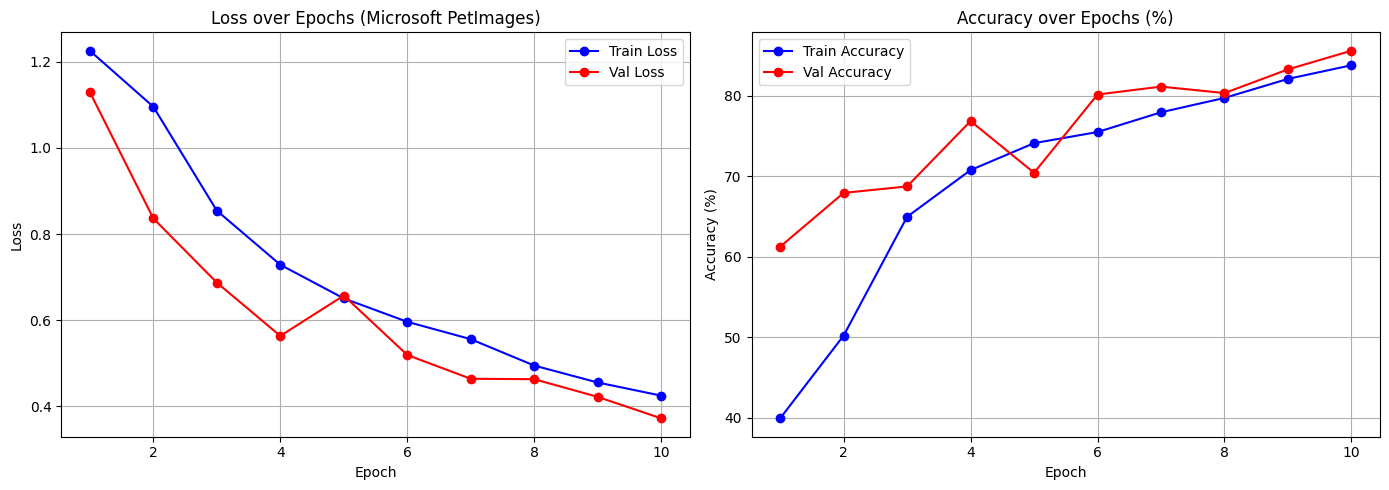

In [18]:
'''
predictions,targets = [],[]
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())
        targets.extend(labels.numpy())

predictions=np.array(predictions)
targets=np.array(targets)
'''

# Final Accuracy
Accuracy=np.mean(predictions==targets)*100
print("*"*40)
print(f"FINAL TEST ACCURACY: {Accuracy:.2f}%")
print("*"*40)
print()
#Confusion Matrix
CM=confusion_matrix(targets, predictions)
print('prediction        glioma     meningioma    notumor    pituitary')
for i in range(len(CM)):
  print('actual',class_names[i],end='          ')
  for j in range(len(CM[0])):
    print(CM[i][j],end='       ')
  print()
print(CM)
print()
# 3. Classification Report
report=classification_report(targets , predictions, target_names=class_names)
print("-------------------- Classification Report ----------------------------")
print(report)
print('-----------------------------------------------------------------------')


fig , (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax1.plot(range(1, epochs + 1), train_loss, label='Train Loss', color='blue', marker='o')
ax1.plot(range(1, epochs + 1), test_loss, label='Val Loss', color='red', marker='o')
ax1.set_title('Loss over Epochs (Microsoft PetImages)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(range(1, epochs + 1), train_acc, label='Train Accuracy', color='blue', marker='o')
ax2.plot(range(1, epochs + 1), test_acc, label='Val Accuracy', color='red', marker='o')
ax2.set_title('Accuracy over Epochs (%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()